In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Polynomail_regression-Prac-D2.csv to Polynomail_regression-Prac-D2.csv


In [3]:
#Read exel file
df = pd.read_csv('Polynomail_regression-Prac-D2.csv')
# Display first  rows
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [4]:
print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB
None

Summary Statistics:
               No  X1 transaction date  X2 house age  \
count  414.000000           414.000000    414.000000   
me

In [5]:
df.shape

(414, 8)

In [6]:
df.isnull().any()

,0
No,False
X1 transaction date,False
X2 house age,False
X3 distance to the nearest MRT station,False
X4 number of convenience stores,False
X5 latitude,False
X6 longitude,False
Y house price of unit area,False


In [7]:
df

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,410,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5


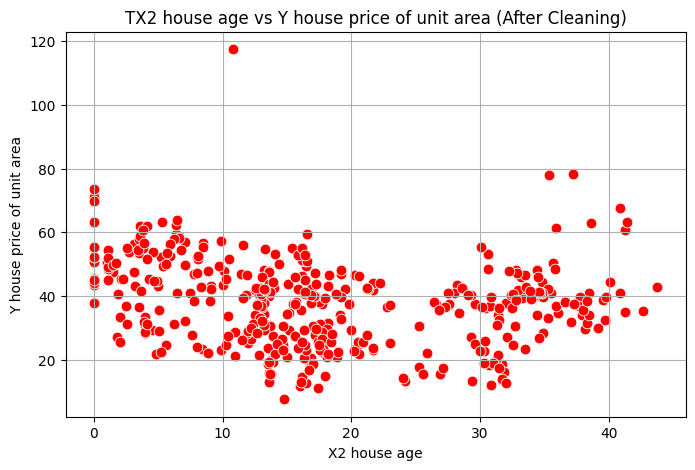

In [23]:
# Visualization to verify
plt.figure(figsize=(8,5))
sns.scatterplot(x='X2 house age', y='Y house price of unit area', data=df, color='red', s=60)
plt.title("TX2 house age vs Y house price of unit area (After Cleaning)")
plt.xlabel("X2 house age")
plt.ylabel("Y house price of unit area")
plt.grid(True)
plt.show()

In [ ]:
#Objective:
# predicts  house price of unit area

In [16]:

# Independent and dependent variables
X = df[['X2 house age']].values
y = df['Y house price of unit area'].values

In [17]:
# Step 3: Linear Regression (Baseline)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_linear = lin_reg.predict(X)
r2_linear = r2_score(y, y_pred_linear)

In [18]:
# Step 4: Polynomial Regression (Degree 2 and 3)

# Degree 2 (Quadratic)
poly2 = PolynomialFeatures(degree=2)
X_poly2 = poly2.fit_transform(X)

poly_reg2 = LinearRegression()
poly_reg2.fit(X_poly2, y)
y_pred_poly2 = poly_reg2.predict(X_poly2)
r2_poly2 = r2_score(y, y_pred_poly2)

In [19]:
# Degree 3 (Cubic) - optional comparison
poly3 = PolynomialFeatures(degree=3)
X_poly3 = poly3.fit_transform(X)

poly_reg3 = LinearRegression()
poly_reg3.fit(X_poly3, y)
y_pred_poly3 = poly_reg3.predict(X_poly3)
r2_poly3 = r2_score(y, y_pred_poly3)

In [20]:
# Step 5: Evaluate Models
print("\nModel Performance Comparison:")
print(f"Linear Regression R² Score: {r2_linear:.4f}")
print(f"Polynomial (Degree 2) R² Score: {r2_poly2:.4f}")
print(f"Polynomial (Degree 3) R² Score: {r2_poly3:.4f}")


Model Performance Comparison:
Linear Regression R² Score: 0.0443
Polynomial (Degree 2) R² Score: 0.2015
Polynomial (Degree 3) R² Score: 0.2045


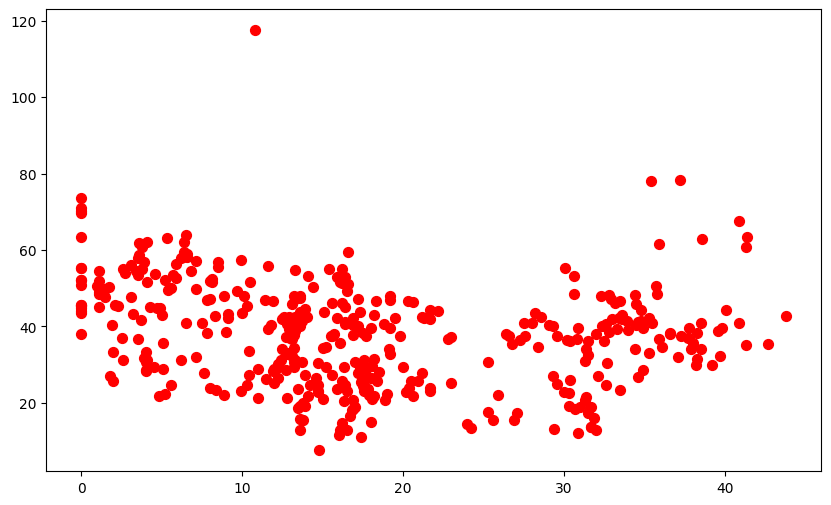

In [21]:
plt.figure(figsize=(10,6))

# Scatter plot of original data
plt.scatter(X, y, color='red', s=50, label='Actual Data')

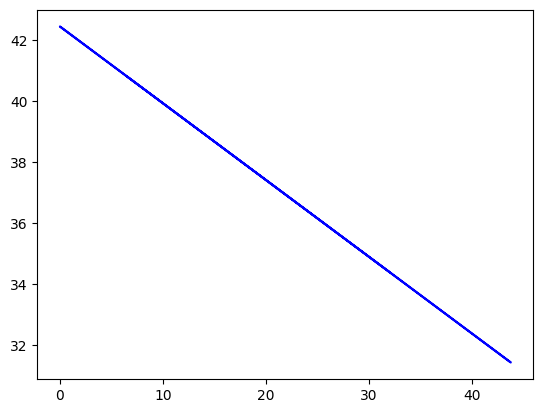

In [24]:
# Linear Regression line
plt.plot(X, y_pred_linear, color='blue', label=f'Linear Fit (R²={r2_linear:.3f})')

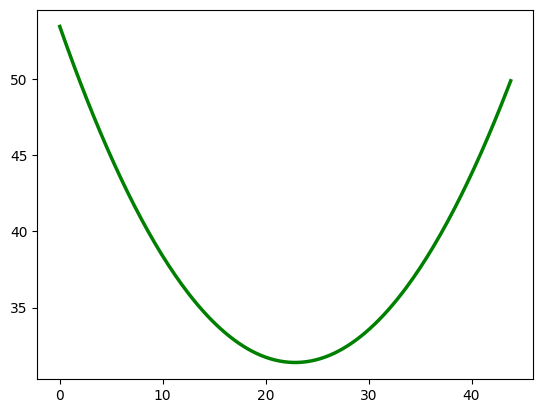

In [25]:
# Polynomial (Degree 2) curve
X_grid = np.linspace(min(X), max(X), 200).reshape(-1,1)
plt.plot(X_grid, poly_reg2.predict(poly2.transform(X_grid)), color='green', linewidth=2.5,
         label=f'Polynomial (Degree 2) Fit (R²={r2_poly2:.3f})')

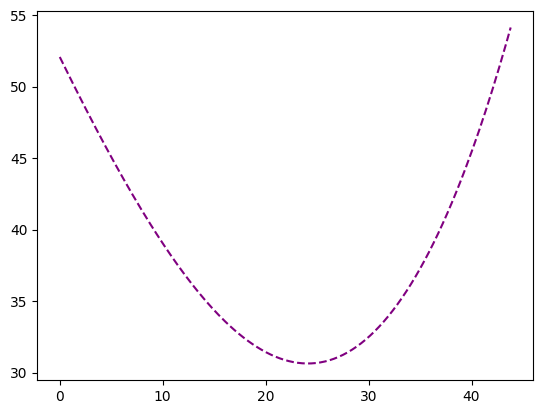

In [26]:
# Polynomial (Degree 3) curve
plt.plot(X_grid, poly_reg3.predict(poly3.transform(X_grid)), color='purple', linestyle='--',
         label=f'Polynomial (Degree 3) Fit (R²={r2_poly3:.3f})')

In [27]:
# Step 7: Model Evaluation Metrics
from sklearn.metrics import mean_squared_error

mse_poly2 = mean_squared_error(y, y_pred_poly2)
mse_poly3 = mean_squared_error(y, y_pred_poly3)

print("\nPolynomial Regression Model Details:")
print(f"Degree 2 Coefficients: {poly_reg2.coef_}")
print(f"Degree 2 Intercept: {poly_reg2.intercept_}")
print(f"Degree 2 MSE: {mse_poly2:.4f}")

print(f"\nDegree 3 Coefficients: {poly_reg3.coef_}")
print(f"Degree 3 Intercept: {poly_reg3.intercept_}")
print(f"Degree 3 MSE: {mse_poly3:.4f}")


Polynomial Regression Model Details:
Degree 2 Coefficients: [ 0.         -1.92887695  0.04218092]
Degree 2 Intercept: 53.45053903402764
Degree 2 MSE: 147.4669

Degree 3 Coefficients: [ 0.00000000e+00 -1.46678630e+00  1.09696361e-02  5.38684522e-04]
Degree 3 Intercept: 52.09643373291592
Degree 3 MSE: 146.9248
